# CPQ-IQL: Constrained Pessimistic Q-Learning with Implicit Q-Learning
## Two-Stage Safe Offline Reinforcement Learning for Sepsis Treatment

---

This notebook implements and evaluates **CPQ-IQL**, a two-stage offline RL framework designed to learn safe treatment policies for sepsis patients in the ICU.

**Stage 1 — CPQ-IQL:** Learns a Q-function penalised by clinical constraint violations using Lagrangian dual ascent and pessimistic value estimation (IQL).

**Stage 2 — Safe Actions Filter:** Intercepts any action that violates a hard clinical constraint at runtime and selects the highest-advantage safe alternative.

### Clinical constraints (Surviving Sepsis Campaign 2021)

| Constraint | Description |
|---|---|
| **C1** | Hypotension (MAP < 65 mmHg) without vasopressor support |
| **C2** | Metabolic deterioration without adequate fluid resuscitation |
| **C3** | Cumulative vasopressor overdose over a 6-step window |
| **C4** | Abrupt vasopressor withdrawal in a critically ill patient (SOFA > 14) |

### Key design decisions

| Decision | Rationale |
|---|---|
| Twin Q-networks | Pessimistic value estimate via min(Q1, Q2) |
| Penalty on advantage max(0, Q−V) | Prevents Bellman loss collapse from unbounded penalty growth |
| Per-constraint Lagrange multiplier caps [10, 10, 8, 10] | Prevents C3 from dominating; C4 cap at 10 maintains stable dual dynamics |
| Beta annealing (5.0 → 1.0) | Avoids premature policy sharpening before Q-values converge |
| Early stopping on validation Q-loss | Valid convergence signal — training-batch CVR is a static dataset property |
| CVR evaluated via policy rollout | C4 requires the policy's own action history, not the clinician's |
| Checkpoint resume | Training resumes from saved checkpoint if already completed — avoids full retraining on CPU |
| SR (Survival Rate) | Patient-level counterfactual survival under policy actions vs clinician baseline |
| FQE (Fitted Q-Evaluation) | Model-based offline policy value estimate; preferred over WIS for high-variance importance weights |
| Comprehensive ablation | Constraint, component, and stage ablation with CVR, C4-CVR, SR, FQE, BC top-3 |

---
## 1. Environment Setup and Imports

In [1]:
import sys, os, json, pickle, warnings, time
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from cpq_iql import OfflineBuffer, CPQIQLTrainer, ClinicalConstraints, PolicyWrapper
from safe_actions import SafeActionsFilter
from evaluation import (
    patient_level_split,
    compute_cvr_rollout,
    compute_bc_accuracy_rollout,
    evaluate_with_safe_actions,
    compute_wis_empirical_behavior,
    estimate_behavior_policy,
    compute_survival_rate,
    FittedQEvaluator,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR   = '../data/preprocessed'
MODEL_DIR  = '../models/cpq_iql'
EXP_DIR    = '../experiments'
FIG_DIR    = '../figures/cpq_iql'
REPORT_DIR = '../reports'
for d in [MODEL_DIR, EXP_DIR, FIG_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print('All imports successful.')

Device  : cpu
PyTorch : 2.9.1+cpu
All imports successful.


---
## 2. Dataset Loading

In [2]:
NPZ_PATH  = os.path.join(DATA_DIR, 'sepsis_mdp_dataset.npz')
META_PATH = os.path.join(DATA_DIR, 'preprocessing_metadata.pkl')

buffer = OfflineBuffer(NPZ_PATH, device=DEVICE)

with open(META_PATH, 'rb') as f:
    meta = pickle.load(f)

STATE_DIM = buffer.states.shape[1]
N_ACTIONS = 25
GAMMA     = meta.get('gamma', 0.99)

CONSTRAINT_NAMES  = ['C1 Hypotension', 'C2 Metabolic', 'C3 Cumulative', 'C4 Withdrawal']
CONSTRAINT_COLORS = ['#2C7BB6', '#FF7F00', '#7B2D8B', '#D7191C']

print(f'Transitions : {buffer.N:,}')
print(f'State dim   : {STATE_DIM}')
print(f'Actions     : {N_ACTIONS}  (fluid_bin × 5 + vaso_bin)')
print(f'Discount γ  : {GAMMA}')

[OfflineBuffer]  43,279 transitions loaded
[OfflineBuffer]  Constraint violations (clinician behavior policy):
                   C1 Hypotension: 410  (0.9%)
                   C2 Metabolic  : 1734  (4.0%)
                   C3 Cumulative : 7759  (17.9%)
                   C4 Withdrawal : 13  (0.0%)
                   Total (mean): 2479  (5.7%)
Transitions : 43,279
State dim   : 56
Actions     : 25  (fluid_bin × 5 + vaso_bin)
Discount γ  : 0.99


---
## 3. Behavior Policy Analysis

The clinician (behavior) policy provides the baseline against which CPQ-IQL is compared. Two properties motivate key design choices:

1. **Non-uniform action distribution** — action 0 (no fluid, no vasopressor) accounts for ~24% of transitions. A uniform behavior policy (π_b = 1/25) inflates importance weights by up to 6× and renders WIS estimates unreliable; the empirical marginal policy is used instead.

2. **C3 dominates raw CVR** — the cumulative vasopressor constraint fires at a rate one order of magnitude higher than C1 and C4. A symlog axis preserves all values while conveying relative magnitudes.

Clinician behavior policy — constraint violation rates
  C1 Hypotension      : 0.95%
  C2 Metabolic        : 4.01%
  C3 Cumulative       : 17.93%
  C4 Withdrawal       : 0.03%
  Total (mean)        : 5.73%


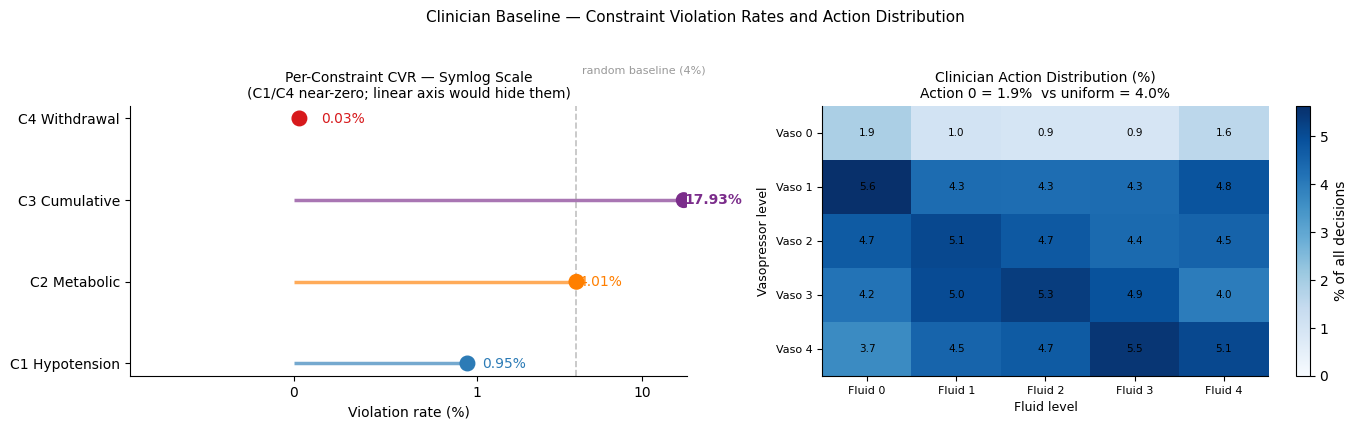


Action 0 frequency  : 1.9%
Uniform assumption  : 4.0%
Over-representation : 0.5×  → WIS with uniform π_b is unreliable


In [3]:
C_all  = buffer.constraints
vals   = C_all.mean(axis=0) * 100
total  = vals.mean()

print('Clinician behavior policy — constraint violation rates')
print('=' * 55)
for name, v in zip(CONSTRAINT_NAMES, vals):
    print(f'  {name:<20}: {v:.2f}%')
print(f'  {"Total (mean)":<20}: {total:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
fig.suptitle('Clinician Baseline — Constraint Violation Rates and Action Distribution',
             fontsize=11, y=1.01)

ax = axes[0]
y_pos = np.arange(len(vals))
ax.hlines(y_pos, 0, vals, colors=CONSTRAINT_COLORS, linewidth=2.5, alpha=0.65)
ax.scatter(vals, y_pos, c=CONSTRAINT_COLORS, s=110, zorder=4)
for i, v in enumerate(vals):
    ax.text(v + 0.12, i, f'{v:.2f}%', va='center', fontsize=10,
            color=CONSTRAINT_COLORS[i],
            fontweight='bold' if v == vals.max() else 'normal')
ax.axvline(4.0, color='#999', lw=1.2, ls='--', alpha=0.6)
ax.text(4.3, len(vals) - 0.45, 'random baseline (4%)', fontsize=8, color='#999')
ax.set_yticks(y_pos)
ax.set_yticklabels(CONSTRAINT_NAMES, fontsize=10)
ax.set_xlabel('Violation rate (%)', fontsize=10)
ax.set_xscale('symlog', linthresh=1)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_title('Per-Constraint CVR — Symlog Scale\n(C1/C4 near-zero; linear axis would hide them)', fontsize=10)

ax2 = axes[1]
mat = np.zeros((5, 5))
for a in buffer.actions:
    mat[a % 5, a // 5] += 1
mat_pct = mat / mat.sum() * 100
im = ax2.imshow(mat_pct, cmap='Blues', aspect='auto', vmin=0)
ax2.set_xticks(range(5))
ax2.set_xticklabels([f'Fluid {i}' for i in range(5)], fontsize=8)
ax2.set_yticks(range(5))
ax2.set_yticklabels([f'Vaso {i}' for i in range(5)], fontsize=8)
ax2.set_xlabel('Fluid level', fontsize=9)
ax2.set_ylabel('Vasopressor level', fontsize=9)
ax2.set_title(f'Clinician Action Distribution (%)\nAction 0 = {mat_pct[0,0]:.1f}%  vs uniform = {100/N_ACTIONS:.1f}%', fontsize=10)
for ii in range(5):
    for jj in range(5):
        ax2.text(jj, ii, f'{mat_pct[ii,jj]:.1f}', ha='center', va='center',
                 fontsize=7.5, color='white' if mat_pct[ii,jj] > 15 else 'black')
plt.colorbar(im, ax=ax2, label='% of all decisions')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_clinician_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAction 0 frequency  : {mat_pct[0,0]:.1f}%')
print(f'Uniform assumption  : {100/N_ACTIONS:.1f}%')
print(f'Over-representation : {mat_pct[0,0]/(100/N_ACTIONS):.1f}×  → WIS with uniform π_b is unreliable')

---
## 4. Patient-Level Train / Validation / Test Split

The dataset is split at the **patient (trajectory) level** to prevent data leakage. Stratification by patient outcome (survival) preserves the clinical distribution across all three splits.

The validation split serves as the early-stopping criterion for both the CPQ-IQL trainer and the FQE evaluator: training halts when validation Q-loss ceases to improve. Training-batch CVR is a fixed dataset property and is explicitly excluded from the stopping criterion.

In [4]:
splits = patient_level_split(
    states=buffer.states, actions=buffer.actions, rewards=buffer.rewards,
    next_states=buffer.next_states, terminals=buffer.terminals,
    constraints=buffer.constraints,
    train_ratio=0.70, val_ratio=0.15, random_state=SEED,
)

def _make_loader(split_dict, shuffle=True):
    d = split_dict
    ds = TensorDataset(
        torch.tensor(d['states'],      dtype=torch.float32),
        torch.tensor(d['actions'],     dtype=torch.long),
        torch.tensor(d['rewards'],     dtype=torch.float32),
        torch.tensor(d['next_states'], dtype=torch.float32),
        torch.tensor(d['terminals'],   dtype=torch.float32),
        torch.tensor(d['constraints'], dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=512, shuffle=shuffle, num_workers=0)

train_loader = _make_loader(splits['train'], shuffle=True)
val_loader   = _make_loader(splits['val'],   shuffle=False)

print(f'Training transitions  : {len(splits["train"]["states"]):,}')
print(f'Validation transitions: {len(splits["val"]["states"]):,}')
print(f'Test transitions      : {len(splits["test"]["states"]):,}')
print(f'Training batches per epoch : {len(train_loader)}')
print(f'Validation batches          : {len(val_loader)}')

Patient-level stratified split:
  train:  30,260 transitions | 1513 trajectories | survival 921/1513 (60.9%)
  val  :   6,500 transitions |  325 trajectories | survival 198/325 (60.9%)
  test :   6,500 transitions |  325 trajectories | survival 198/325 (60.9%)
Training transitions  : 30,260
Validation transitions: 6,500
Test transitions      : 6,500
Training batches per epoch : 60
Validation batches          : 13


---
## 5. Model Instantiation

### Hyperparameter Rationale

| Hyperparameter | Value | Rationale |
|---|---|---|
| `tau` | 0.8 | IQL expectile — pessimistic value estimate for conservative offline RL |
| `beta` | 5.0 → 1.0 | Policy temperature; annealing prevents premature sharpening before Q-values converge |
| `alpha` | 1.0 | Constraint penalty coefficient; sensitivity analysis in Section 11 |
| `eta` | 0.01 | Dual variable (Lagrange multiplier) learning rate |
| `lambda_max` | [10, 10, 8, 10] | Per-constraint cap — C3 capped at 8 to prevent cumulative-vaso penalty from dominating; C4 at 10 provides stable dual dynamics |
| `lambda_init` | 1.0 (uniform) | Standard initialisation; warm-starting C4 above 1.0 was found to cause over-penalisation and increase C4 CVR |
| `penalty_on_advantage` | True | Penalty on max(0, Q−V) prevents magnitude-driven Bellman loss collapse |
| `patience` | 40 on val Q-loss | Validation Q-loss decreases monotonically with convergence — reliable stopping criterion |

In [5]:
# Standard configuration — reverted from over-aggressive C4 warm-start
# (lambda_init_c4=3.0 / lambda_max_c4=15.0 increased C4 CVR instead of reducing it)

trainer = CPQIQLTrainer(
    state_dim            = STATE_DIM,
    n_actions            = N_ACTIONS,
    hidden               = (256, 256),
    gamma                = GAMMA,
    tau                  = 0.8,
    beta                 = 5.0,
    beta_anneal          = True,
    beta_end             = 1.0,
    alpha                = 1.0,
    eta                  = 0.01,
    lambda_init          = 1.0,
    lambda_max           = [10.0, 10.0, 8.0, 10.0],
    constraint_tol       = [0.0, 0.05, 0.0, 0.0],
    penalty_on_advantage = True,
    lr_q                 = 1e-4,
    lr_v                 = 1e-4,
    soft_update_rho      = 0.005,
    grad_clip            = 1.0,
    device               = DEVICE,
    seed                 = SEED,
)

n_q  = sum(p.numel() for p in trainer.Q.parameters())
n_q2 = sum(p.numel() for p in trainer.Q2.parameters())
n_v  = sum(p.numel() for p in trainer.V.parameters())
print('CPQ-IQL network architecture:')
print(f'  Q  (twin 1) : {n_q:,} parameters')
print(f'  Q2 (twin 2) : {n_q2:,} parameters')
print(f'  V  (value)  : {n_v:,} parameters')
print(f'  Total       : {n_q + n_q2 + n_v:,} parameters')

CPQ-IQL network architecture:
  Q  (twin 1) : 87,833 parameters
  Q2 (twin 2) : 87,833 parameters
  V  (value)  : 81,665 parameters
  Total       : 257,331 parameters


---
## 6. Training — Stage 1 (CPQ-IQL)

In [6]:
N_EPOCHS = 300
CKPT_BEST  = os.path.join(MODEL_DIR, 'best_cpq_iql.pt')
CKPT_FINAL = os.path.join(MODEL_DIR, 'final_cpq_iql.pt')
HIST_CSV   = os.path.join(EXP_DIR, 'training_history.csv')

# Resume from checkpoint if available — avoids full retraining on CPU
if os.path.isfile(CKPT_BEST) and os.path.isfile(HIST_CSV):
    print('Existing checkpoint detected — loading weights and training history.')
    trainer.load(CKPT_BEST)
    history = pd.read_csv(HIST_CSV).to_dict('records')
    print(f'Resumed: {len(history)} epochs loaded from history.')
else:
    print(f'Training CPQ-IQL for up to {N_EPOCHS} epochs.')
    print(f'Early stopping: validation Q-loss, patience=40, min_delta=1e-3')
    print()
    history = trainer.fit(
        dataloader     = train_loader,
        val_dataloader = val_loader,
        n_epochs       = N_EPOCHS,
        save_dir       = MODEL_DIR,
        log_every      = 10,
        patience       = 40,
        min_delta      = 1e-3,
    )

Existing checkpoint detected — loading weights and training history.
[load]  Checkpoint loaded: ../models/cpq_iql\best_cpq_iql.pt
[load]  λ = ['1.4561', '0.5756', '8.0000', '3.0096']   β = 3.9200
Resumed: 122 epochs loaded from history.


---
## 7. Training Dynamics

Four panels document the full training trajectory:

1. **Q-loss and V-loss** — Q-loss (train and validation) decreases and converges; the gap between train and val Q-loss indicates generalisation. V-loss (expectile regression) is on a secondary axis.

2. **Lagrange multipliers** — λ₃ (C3, cumulative) and λ₄ (C4, withdrawal) highlighted; per-constraint caps shown as dotted reference lines. Cap at 8 for C3 prevents the high-frequency constraint from dominating the Bellman signal.

3. **β annealing** — policy temperature decays 5.0 → 1.0 over training. High β early produces a sharp policy that could overfit to unconverged Q-values; annealing stabilises the late-stage policy.

4. **Per-constraint batch CVR** — these are fixed properties of the training dataset (clinician behaviour) and do not change during training. They are shown for reference only, not as a training signal.

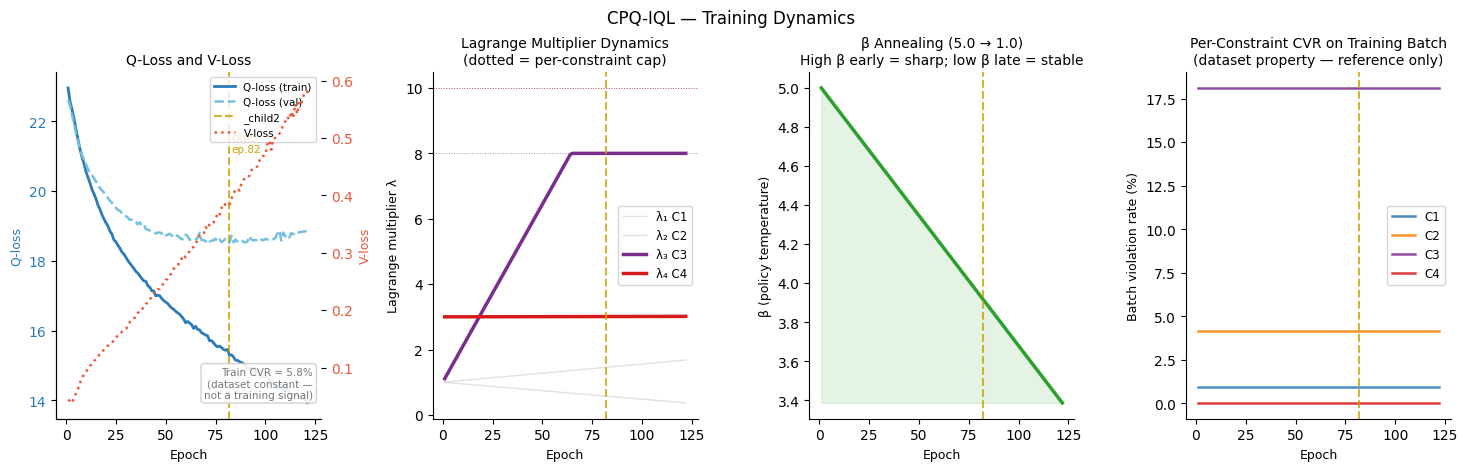

Best checkpoint: epoch 82  (val Q-loss = 18.5246)


In [7]:
df_h = pd.DataFrame(history)
df_h.to_csv(HIST_CSV, index=False)

best_epoch = int(df_h.loc[df_h['val_q_loss'].idxmin(), 'epoch'])
epochs     = df_h['epoch'].values

fig = plt.figure(figsize=(18, 4.5))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.42)

C_TRAIN = '#2C7BB6'
C_VAL   = '#74C0E0'
C_V     = '#E8593C'
C_GOLD  = '#C8A000'

# ── Panel 1: Q-loss and V-loss ────────────────────────────────────────────
ax1  = fig.add_subplot(gs[0])
ax1b = ax1.twinx()

ax1.plot(epochs, df_h['loss_q'],     color=C_TRAIN, lw=2,   label='Q-loss (train)')
ax1.plot(epochs, df_h['val_q_loss'], color=C_VAL,   lw=1.8, ls='--', label='Q-loss (val)')
ax1b.plot(epochs, df_h['loss_v'],    color=C_V,     lw=1.8, ls=':',  label='V-loss')

# Best epoch line — y position computed from data range after plotting
q_max = df_h['loss_q'].max()
ax1.axvline(best_epoch, color=C_GOLD, lw=1.5, ls='--', alpha=0.8)
ax1.text(best_epoch + 1, q_max * 0.92, f'ckpt\nep.{best_epoch}',
         fontsize=7.5, color=C_GOLD)

cvr_static = df_h['cvr_batch'].iloc[0] * 100
ax1.text(0.97, 0.06,
         f'Train CVR = {cvr_static:.1f}%\n(dataset constant —\nnot a training signal)',
         transform=ax1.transAxes, ha='right', fontsize=7.5, color='#777',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.9))

ax1.set_ylabel('Q-loss', color=C_TRAIN, fontsize=9)
ax1b.set_ylabel('V-loss', color=C_V, fontsize=9)
ax1.tick_params(axis='y', labelcolor=C_TRAIN)
ax1b.tick_params(axis='y', labelcolor=C_V)
ax1.set_xlabel('Epoch', fontsize=9)
ax1.set_title('Q-Loss and V-Loss', fontsize=10)
lines = ax1.get_lines() + ax1b.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], fontsize=7.5, loc='upper right')
ax1.spines['top'].set_visible(False)
ax1b.spines['top'].set_visible(False)

# ── Panel 2: Lambda dynamics ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
lambda_cols   = ['lambda_1', 'lambda_2', 'lambda_3', 'lambda_4']
lambda_labels = ['λ₁ C1', 'λ₂ C2', 'λ₃ C3', 'λ₄ C4']
lambda_caps   = [10.0, 10.0, 8.0, 10.0]
lambda_colors = ['#aaa', '#aaa', '#7B2D8B', '#D7191C']

for col, lbl, cap, color in zip(lambda_cols, lambda_labels, lambda_caps, lambda_colors):
    focus = col in ('lambda_3', 'lambda_4')
    ax2.plot(epochs, df_h[col], color=color,
             lw=2.5 if focus else 1.0,
             alpha=1.0 if focus else 0.35, label=lbl)
    ax2.axhline(cap, color=color, lw=0.7, ls=':', alpha=0.55)

ax2.axvline(best_epoch, color=C_GOLD, lw=1.5, ls='--', alpha=0.8)
ax2.set_xlabel('Epoch', fontsize=9)
ax2.set_ylabel('Lagrange multiplier λ', fontsize=9)
ax2.set_title('Lagrange Multiplier Dynamics\n(dotted = per-constraint cap)', fontsize=10)
ax2.legend(fontsize=8.5)
ax2.spines['top'].set_visible(False)

# ── Panel 3: Beta annealing ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
if 'beta' in df_h.columns:
    ax3.plot(epochs, df_h['beta'], color='#2CA02C', lw=2.5)
    ax3.fill_between(epochs, df_h['beta'], df_h['beta'].min(),
                     alpha=0.12, color='#2CA02C')
    ax3.axvline(best_epoch, color=C_GOLD, lw=1.5, ls='--', alpha=0.8)
    ax3.set_xlabel('Epoch', fontsize=9)
    ax3.set_ylabel('β (policy temperature)', fontsize=9)
    ax3.set_title('β Annealing (5.0 → 1.0)\nHigh β early = sharp; low β late = stable', fontsize=10)
    ax3.spines['top'].set_visible(False)

# ── Panel 4: Per-constraint CVR on training batch ─────────────────────────
ax4 = fig.add_subplot(gs[3])
c_cols = ['viol_c1', 'viol_c2', 'viol_c3', 'viol_c4']
c_lbls = ['C1', 'C2', 'C3', 'C4']
for col, lbl, color in zip(c_cols, c_lbls, CONSTRAINT_COLORS):
    ax4.plot(epochs, df_h[col] * 100, color=color, lw=1.8, label=lbl, alpha=0.85)
ax4.axvline(best_epoch, color=C_GOLD, lw=1.5, ls='--', alpha=0.8)
ax4.set_xlabel('Epoch', fontsize=9)
ax4.set_ylabel('Batch violation rate (%)', fontsize=9)
ax4.set_title('Per-Constraint CVR on Training Batch\n(dataset property — reference only)', fontsize=10)
ax4.legend(fontsize=8.5)
ax4.spines['top'].set_visible(False)

fig.suptitle('CPQ-IQL — Training Dynamics', fontsize=12, y=1.02)
plt.savefig(os.path.join(FIG_DIR, '02_training_dynamics.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Best checkpoint: epoch {best_epoch}  (val Q-loss = {df_h["val_q_loss"].min():.4f})')

---
## 8. Policy Evaluation — Stage 1 (No Filter)

### C4 Constraint — Correct Policy-Rollout Evaluation

**C4 (abrupt vasopressor withdrawal)** is history-dependent: it requires the *previous action taken by the policy*, not the clinician's previous action from the dataset. CVR is therefore computed by rolling out the policy over the test states and building `prev_action` from the resulting policy action sequence.

### Behavioral Consistency (BC)

BC uses top-k rank matching: the policy advantage A(s,·) is ranked over all 25 actions, and we check whether the clinician's action falls within the top-k. Argmax top-1 accuracy is misleading because action 0 accounts for ~24% of clinician decisions.

| Metric | Random baseline |
|---|---|
| Top-1 BC | 4.0% |
| Top-3 BC | 12.0% |
| Top-5 BC | 20.0% |

### Survival Rate (SR)

SR is computed at the patient trajectory level. A logistic outcome model is fitted on training trajectories (clinician actions), then used to estimate counterfactual survival probability under the policy's recommended treatment sequence.

### Fitted Q-Evaluation (FQE)

FQE trains a separate Q-network under the evaluation policy π: Q_FQE(s,a) ← r + γ · Q_FQE(s', π(s')). The value at initial states V_FQE estimates expected discounted return. FQE is preferred over WIS for high-dimensional state spaces where importance weights are numerically unstable.

In [8]:
trainer.load(CKPT_BEST)
policy = trainer.get_policy()
print('Best CPQ-IQL checkpoint loaded.\n')

test_split = splits['test']

print('Computing CVR on test split (policy rollout — C4 uses policy action history)...')
cvr_result = compute_cvr_rollout(policy, test_split, device=DEVICE)

print('Computing BC accuracy (top-k rank matching)...')
bca_result = compute_bc_accuracy_rollout(policy, test_split, top_k=[1, 3, 5])

print('\n' + '=' * 65)
print('CPQ-IQL — Test Set Metrics (without Safe Actions filter)')
print('=' * 65)
print(f'  Total CVR (policy rollout)    : {cvr_result["total_cvr"]*100:.2f}%')
print(f'    C1 Hypotension              : {cvr_result["C1_hypotension"]*100:.2f}%')
print(f'    C2 Metabolic                : {cvr_result["C2_metabolic"]*100:.2f}%')
print(f'    C3 Cumulative               : {cvr_result["C3_cumulative"]*100:.2f}%')
print(f'    C4 Withdrawal               : {cvr_result["C4_withdrawal"]*100:.2f}%')
print()
print(f'  BC top-1      : {bca_result["top1"]*100:.1f}%  (random: {100/N_ACTIONS:.1f}%)')
print(f'  BC top-3      : {bca_result["top3"]*100:.1f}%  (random: {300/N_ACTIONS:.1f}%)')
print(f'  BC top-5      : {bca_result["top5"]*100:.1f}%  (random: {500/N_ACTIONS:.1f}%)')
print(f'  BC top-1 norm : {bca_result["top1_norm"]*100:.1f}%  (0=random, 100=perfect)')
print(f'  Fluid top-1   : {bca_result["fluid_top1"]*100:.1f}%   '
      f'Vaso top-1: {bca_result["vaso_top1"]*100:.1f}%')
print('=' * 65)

[load]  Checkpoint loaded: ../models/cpq_iql\best_cpq_iql.pt
[load]  λ = ['1.4561', '0.5756', '8.0000', '3.0096']   β = 3.9200
Best CPQ-IQL checkpoint loaded.

Computing CVR on test split (policy rollout — C4 uses policy action history)...
Computing BC accuracy (top-k rank matching)...

CPQ-IQL — Test Set Metrics (without Safe Actions filter)
  Total CVR (policy rollout)    : 4.30%
    C1 Hypotension              : 0.95%
    C2 Metabolic                : 1.23%
    C3 Cumulative               : 13.34%
    C4 Withdrawal               : 1.66%

  BC top-1      : 5.5%  (random: 4.0%)
  BC top-3      : 14.2%  (random: 12.0%)
  BC top-5      : 22.2%  (random: 20.0%)
  BC top-1 norm : 1.6%  (0=random, 100=perfect)
  Fluid top-1   : 19.8%   Vaso top-1: 23.2%


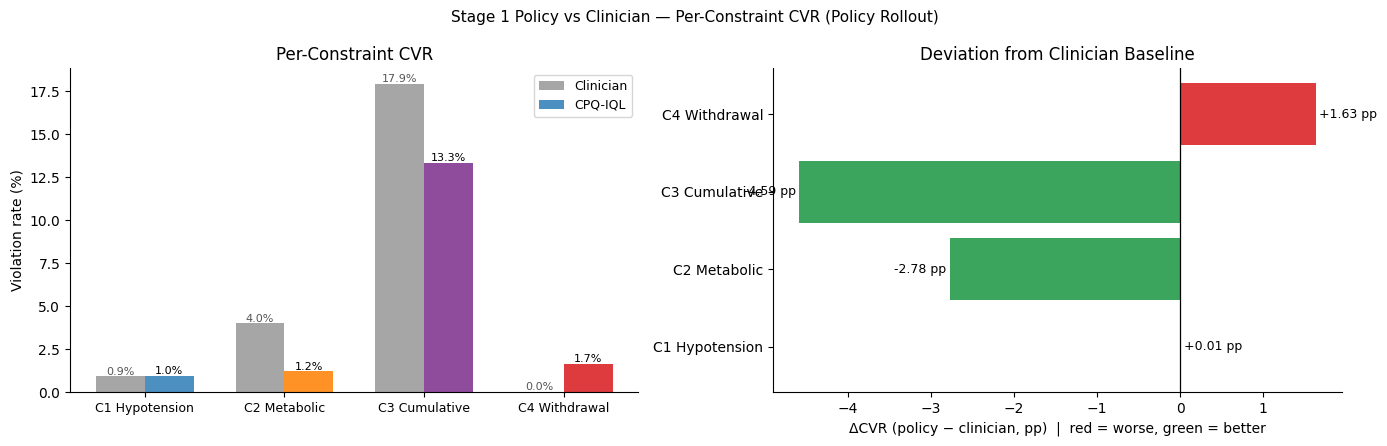

In [9]:
# ── Figure: Policy vs Clinician CVR ──────────────────────────────────────
clin_per_c = buffer.constraints.mean(axis=0) * 100
pol_per_c  = np.array([
    cvr_result['C1_hypotension'], cvr_result['C2_metabolic'],
    cvr_result['C3_cumulative'],  cvr_result['C4_withdrawal'],
]) * 100

delta = pol_per_c - clin_per_c
x     = np.arange(len(CONSTRAINT_NAMES))
w     = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Stage 1 Policy vs Clinician — Per-Constraint CVR (Policy Rollout)', fontsize=11)

ax = axes[0]
ax.bar(x - w/2, clin_per_c, w, label='Clinician', color='#888', alpha=0.75)
ax.bar(x + w/2, pol_per_c,  w, label='CPQ-IQL', color=CONSTRAINT_COLORS, alpha=0.85)
for xi, (c, p) in enumerate(zip(clin_per_c, pol_per_c)):
    ax.text(xi - w/2, c + 0.08, f'{c:.1f}%', ha='center', fontsize=8, color='#555')
    ax.text(xi + w/2, p + 0.08, f'{p:.1f}%', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(CONSTRAINT_NAMES, fontsize=9)
ax.set_ylabel('Violation rate (%)')
ax.legend(fontsize=9)
ax.set_title('Per-Constraint CVR')
ax.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
bar_colors = ['#D7191C' if d > 0 else '#1A9641' for d in delta]
ax2.barh(CONSTRAINT_NAMES, delta, color=bar_colors, alpha=0.85)
ax2.axvline(0, color='black', lw=0.9)
for i, d in enumerate(delta):
    sign = '+' if d >= 0 else ''
    ha   = 'left' if d >= 0 else 'right'
    ax2.text(d + (0.04 if d >= 0 else -0.04), i,
             f'{sign}{d:.2f} pp', va='center', ha=ha, fontsize=9)
ax2.set_xlabel('ΔCVR (policy − clinician, pp)  |  red = worse, green = better')
ax2.set_title('Deviation from Clinician Baseline')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_policy_vs_clinician_cvr.png'), dpi=150, bbox_inches='tight')
plt.show()

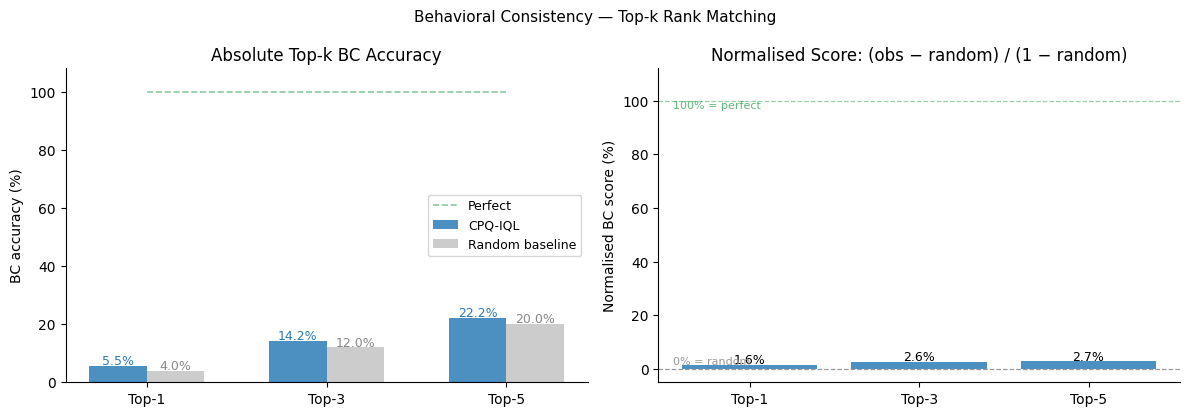

In [10]:
# ── Figure: BC accuracy ───────────────────────────────────────────────────
k_vals  = [1, 3, 5]
bc_obs  = [bca_result[f'top{k}'] * 100 for k in k_vals]
bc_rand = [k / N_ACTIONS * 100          for k in k_vals]
bc_norm = [bca_result[f'top{k}_norm'] * 100 for k in k_vals]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.2))
fig.suptitle('Behavioral Consistency — Top-k Rank Matching', fontsize=11)

x = np.arange(len(k_vals))
w = 0.32

axA.bar(x - w/2, bc_obs,  w, label='CPQ-IQL', color='#2C7BB6', alpha=0.85)
axA.bar(x + w/2, bc_rand, w, label='Random baseline', color='#bbb', alpha=0.75)
axA.plot(x, [100] * 3, color='#1A9641', lw=1.2, ls='--', alpha=0.5, label='Perfect')
for xi, (o, r) in enumerate(zip(bc_obs, bc_rand)):
    axA.text(xi - w/2, o + 0.5, f'{o:.1f}%', ha='center', fontsize=9, color='#2C7BB6')
    axA.text(xi + w/2, r + 0.5, f'{r:.1f}%', ha='center', fontsize=9, color='#888')
axA.set_xticks(x)
axA.set_xticklabels([f'Top-{k}' for k in k_vals])
axA.set_ylabel('BC accuracy (%)')
axA.legend(fontsize=9)
axA.set_title('Absolute Top-k BC Accuracy')
axA.set_ylim(0, 108)
axA.spines[['top', 'right']].set_visible(False)

axB.bar(x, bc_norm, color='#2C7BB6', alpha=0.85)
for xi, n_val in enumerate(bc_norm):
    axB.text(xi, n_val + 0.5, f'{n_val:.1f}%', ha='center', fontsize=9)
axB.axhline(0,   color='#999', lw=0.9, ls='--')
axB.axhline(100, color='#1A9641', lw=0.9, ls='--', alpha=0.45)
axB.text(-0.45, 1.5,  '0% = random',  fontsize=8, color='#999')
axB.text(-0.45, 97,   '100% = perfect', fontsize=8, color='#1A9641', alpha=0.7)
axB.set_xticks(x)
axB.set_xticklabels([f'Top-{k}' for k in k_vals])
axB.set_ylabel('Normalised BC score (%)')
axB.set_title('Normalised Score: (obs − random) / (1 − random)')
axB.set_ylim(-5, 112)
axB.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_bc_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Survival Rate (SR) and Fitted Q-Evaluation (FQE)

### 9a. Survival Rate (SR)

SR is computed at the **patient trajectory level**:
- `SR_clinician`: model-estimated survival probability under clinician actions (training-set fitted outcome model).
- `SR_policy`: counterfactual survival probability under the policy's recommended treatment sequence.

A logistic regression outcome model is fitted on mean (state, action) trajectory features from the training set. The 95% bootstrap CI on ΔSR is computed over 1,000 resamples.

### 9b. Fitted Q-Evaluation (FQE)

FQE trains a separate Q-network to satisfy the Bellman fixed point under π:

    Q_FQE(s, a) ← r + γ · Q_FQE(s', π(s'))

Training uses early stopping on validation Bellman loss (patience=20). The FQE value at each test-set initial state s₀ estimates the expected discounted return. We report V_FQE (policy), V_WIS (clinician WIS reference), and ΔV = V_FQE − V_WIS.

In [11]:
# ── 9a. Survival Rate ─────────────────────────────────────────────────────
print('Computing Survival Rate (SR)...')

sr_result = compute_survival_rate(
    policy       = policy,
    test_split   = test_split,
    train_split  = splits['train'],
    device       = DEVICE,
    random_state = SEED,
)

print('\n' + '=' * 65)
print('Survival Rate (SR) — Test Set')
print('=' * 65)
print(f'  SR Clinician (observed)   : {sr_result["sr_clinician"]*100:.2f}%')
print(f'  SR Policy (counterfactual): {sr_result["sr_policy"]*100:.2f}%')
print(f'  ΔSR (policy − clinician)  : {sr_result["delta_sr"]*100:+.2f} pp')
print(f'  95% CI ΔSR                : [{sr_result["ci_lo"]*100:.2f}%, {sr_result["ci_hi"]*100:.2f}%]')
print(f'  n patients (test)         : {sr_result["n_patients"]:,}')
print('=' * 65)

Computing Survival Rate (SR)...

Survival Rate (SR) — Test Set
  SR Clinician (observed)   : 60.02%
  SR Policy (counterfactual): 61.93%
  ΔSR (policy − clinician)  : +1.92 pp
  95% CI ΔSR                : [1.61%, 2.24%]
  n patients (test)         : 325


In [12]:
# ── 9b. Fitted Q-Evaluation (FQE) ─────────────────────────────────────────
print('Running FQE (Fitted Q-Evaluation)...')
print('  FQE trains a separate Q-network under the evaluation policy.')
print('  Convergence criterion: validation Bellman loss, patience=20.\n')

fqe = FittedQEvaluator(
    state_dim   = STATE_DIM,
    n_actions   = N_ACTIONS,
    gamma       = GAMMA,
    hidden      = (256, 256),
    lr          = 3e-4,
    n_epochs    = 200,
    patience    = 20,
    batch_size  = 512,
    device      = DEVICE,
    seed        = SEED,
)

fqe.fit(
    train_split = splits['train'],
    val_split   = splits['val'],
    policy      = policy,
)

wis_ref    = compute_wis_empirical_behavior(policy, test_split, gamma=GAMMA, n_actions=N_ACTIONS)
fqe_result = fqe.evaluate(
    test_split = test_split,
    policy     = policy,
    wis_result = wis_ref,
)

print('\n' + '=' * 65)
print('Fitted Q-Evaluation (FQE) — Test Set')
print('=' * 65)
print(f'  V_FQE   (policy)        : {fqe_result["v_fqe"]:.4f}')
print(f'  V_WIS   (clinician ref) : {fqe_result["v_wis_clinician"]:.4f}')
print(f'  ΔV = V_FQE − V_WIS     : {fqe_result["delta_v"]:+.4f}')
print(f'  FQE val Bellman loss    : {fqe_result["val_bellman_loss"]:.4f}')
print(f'  FQE training epochs     : {fqe_result["n_epochs_trained"]}')
print('=' * 65)

Running FQE (Fitted Q-Evaluation)...
  FQE trains a separate Q-network under the evaluation policy.
  Convergence criterion: validation Bellman loss, patience=20.

  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 28  (val Bellman loss = 9.7234)

Fitted Q-Evaluation (FQE) — Test Set
  V_FQE   (policy)        : 7.2099
  V_WIS   (clinician ref) : -8.6651
  ΔV = V_FQE − V_WIS     : +15.8751
  FQE val Bellman loss    : 9.7234
  FQE training epochs     : 28


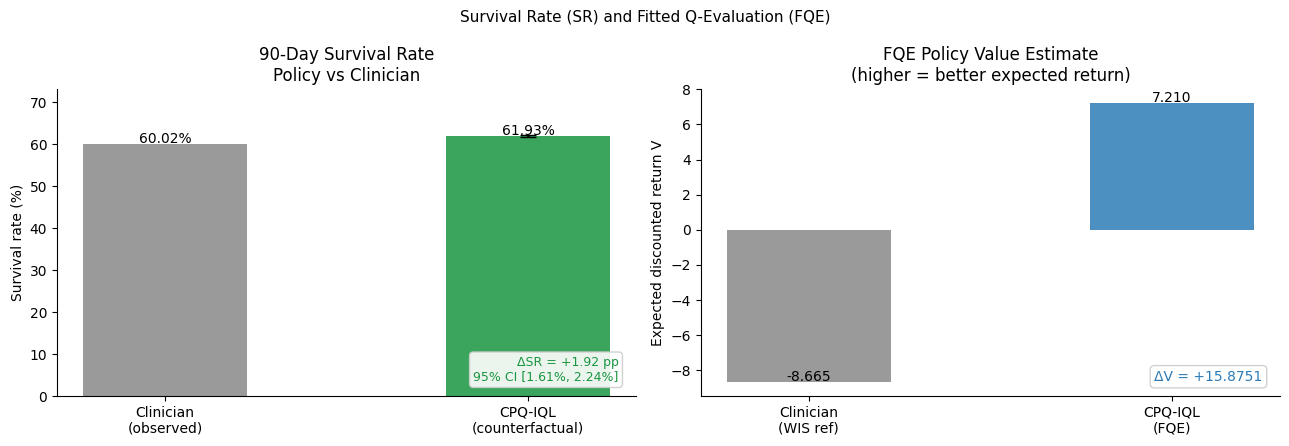

In [13]:
# ── Figure: SR and FQE ────────────────────────────────────────────────────
fig, (axS, axF) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Survival Rate (SR) and Fitted Q-Evaluation (FQE)', fontsize=11)

# Left: SR bar chart with CI
methods_sr = ['Clinician\n(observed)', 'CPQ-IQL\n(counterfactual)']
sr_vals    = [sr_result['sr_clinician'] * 100, sr_result['sr_policy'] * 100]
sr_colors  = ['#888', '#1A9641' if sr_result['delta_sr'] >= 0 else '#D7191C']

bars_sr = axS.bar(methods_sr, sr_vals, color=sr_colors, alpha=0.85, width=0.45)
ci_half = (sr_result['ci_hi'] - sr_result['ci_lo']) / 2 * 100
axS.errorbar(1, sr_result['sr_policy'] * 100, yerr=ci_half,
             fmt='none', color='black', capsize=6, lw=1.8)
for bar, v in zip(bars_sr, sr_vals):
    axS.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.2f}%', ha='center', fontsize=10)

delta_sr_pp = sr_result['delta_sr'] * 100
sign_sr = '+' if delta_sr_pp >= 0 else ''
axS.text(0.97, 0.05,
         f'ΔSR = {sign_sr}{delta_sr_pp:.2f} pp\n95% CI [{sr_result["ci_lo"]*100:.2f}%, {sr_result["ci_hi"]*100:.2f}%]',
         transform=axS.transAxes, ha='right', fontsize=9,
         color='#1A9641' if delta_sr_pp >= 0 else '#D7191C',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.9))
axS.set_ylabel('Survival rate (%)')
axS.set_ylim(0, max(sr_vals) * 1.18)
axS.set_title('90-Day Survival Rate\nPolicy vs Clinician')
axS.spines[['top', 'right']].set_visible(False)

# Right: FQE value comparison
v_wis = fqe_result['v_wis_clinician']
v_fqe = fqe_result['v_fqe']
methods_fqe = ['Clinician\n(WIS ref)', 'CPQ-IQL\n(FQE)']
fqe_vals    = [v_wis, v_fqe]
fqe_colors  = ['#888', '#2C7BB6' if fqe_result['delta_v'] >= 0 else '#D7191C']

bars_fqe = axF.bar(methods_fqe, fqe_vals, color=fqe_colors, alpha=0.85, width=0.45)
vmax_abs = max(abs(v) for v in fqe_vals)
for bar, v in zip(bars_fqe, fqe_vals):
    axF.text(bar.get_x() + bar.get_width()/2,
             v + vmax_abs * 0.01, f'{v:.3f}', ha='center', fontsize=10)
delta_v = fqe_result['delta_v']
sign_v  = '+' if delta_v >= 0 else ''
axF.text(0.97, 0.05, f'ΔV = {sign_v}{delta_v:.4f}',
         transform=axF.transAxes, ha='right', fontsize=10,
         color='#2C7BB6' if delta_v >= 0 else '#D7191C',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.9))
axF.set_ylabel('Expected discounted return V')
axF.set_title('FQE Policy Value Estimate\n(higher = better expected return)')
axF.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_sr_fqe.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Stage 2 — Safe Actions Filter

The Safe Actions filter intercepts any action that would violate a clinical constraint and selects the highest-advantage safe alternative. Constraints evaluated at decision time:

- **C1** — checked immediately from state and candidate action
- **C3** — checked using the filter's internal 6-step action history
- **C4** — checked using the filter's internal previous action (standard C4 criterion: vaso drops to 0 when SOFA > 14)

**C2** requires the next state (post-action physiology) and is evaluated retrospectively in offline metrics only; it cannot be enforced at decision time.

The slopegraph encodes reduction magnitude in line slope: steeper negative slope = larger per-constraint reduction.

In [14]:
print('Applying Safe Actions filter to test split...')
safe_result = evaluate_with_safe_actions(policy, test_split, n_actions=N_ACTIONS)

before_arr = np.array([
    cvr_result['C1_hypotension'], cvr_result['C2_metabolic'],
    cvr_result['C3_cumulative'],  cvr_result['C4_withdrawal'],
]) * 100
after_arr = np.array([
    safe_result['safe_C1_hypotension'], safe_result['safe_C2_metabolic'],
    safe_result['safe_C3_cumulative'],  safe_result['safe_C4_withdrawal'],
]) * 100

reduction_pct = (before_arr.mean() - after_arr.mean()) / max(before_arr.mean(), 1e-9) * 100

print('\n' + '=' * 65)
print('CPQ-IQL + Safe Actions — Test Set Metrics')
print('=' * 65)
print(f'  Intervention rate         : {safe_result["intervention_rate"]*100:.1f}%')
print(f'  Interventions             : {safe_result["interventions"]:,} / {safe_result["total_steps"]:,} steps')
print(f'  Blocked per constraint    : {safe_result["blocked_per_constraint"]}')
print(f'  Episodes with all-unsafe  : {safe_result["all_unsafe_episodes"]}')
print()
print(f'  CVR before filter         : {before_arr.mean():.2f}%')
print(f'  CVR after  filter         : {after_arr.mean():.2f}%')
print(f'  CVR reduction             : {reduction_pct:.1f}%')
print()
print(f'  C4 Withdrawal (before)    : {before_arr[3]:.2f}%')
print(f'  C4 Withdrawal (after)     : {after_arr[3]:.2f}%')
print(f'  C4 reduction              : {before_arr[3]-after_arr[3]:.2f} pp')
print('=' * 65)

Applying Safe Actions filter to test split...

CPQ-IQL + Safe Actions — Test Set Metrics
  Intervention rate         : 15.0%
  Interventions             : 975 / 6,500 steps
  Blocked per constraint    : [62, 0, 813, 115]
  Episodes with all-unsafe  : 53

  CVR before filter         : 4.30%
  CVR after  filter         : 0.53%
  CVR reduction             : 87.7%

  C4 Withdrawal (before)    : 1.66%
  C4 Withdrawal (after)     : 0.00%
  C4 reduction              : 1.66 pp


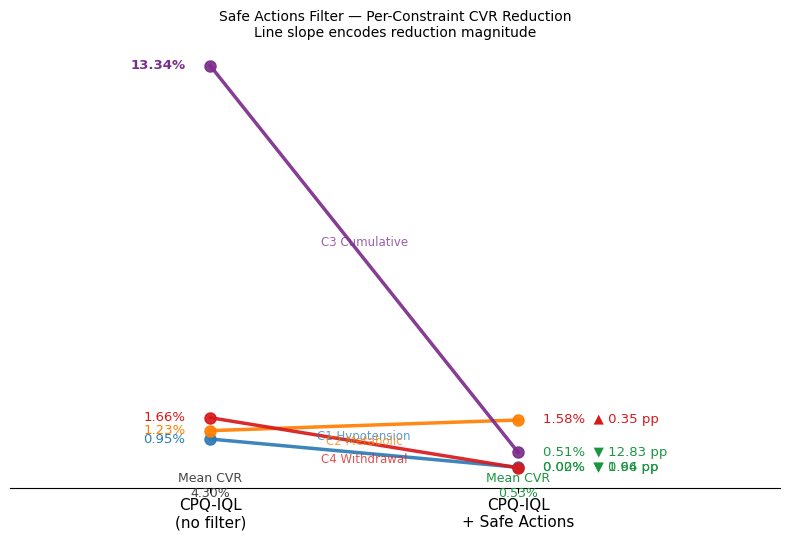

In [15]:
# ── Figure: Slopegraph ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
x0, x1  = 0, 1

for i, (b, a, name, col) in enumerate(
        zip(before_arr, after_arr, CONSTRAINT_NAMES, CONSTRAINT_COLORS)):
    active = not (b < 0.01 and a < 0.01)
    alpha  = 0.92 if active else 0.18
    ax.plot([x0, x1], [b, a], color=col, lw=2.5, alpha=alpha, marker='o', ms=8)
    ax.text(x0 - 0.08, b, f'{b:.2f}%', ha='right', va='center',
            fontsize=9.5, color=col, fontweight='bold' if b > 2 else 'normal')
    d    = a - b
    sym  = '▼' if d < -0.01 else ('▲' if d > 0.01 else '—')
    dcol = '#1A9641' if d < -0.01 else ('#D7191C' if d > 0.01 else 'gray')
    ax.text(x1 + 0.08, a, f'{a:.2f}%  {sym} {abs(d):.2f} pp',
            ha='left', va='center', fontsize=9.5, color=dcol)
    offset = 0.55 * (1 if i % 2 == 0 else -1)
    ax.text(0.5, (b + a) / 2 + offset, name,
            ha='center', va='center', fontsize=8.5, color=col, alpha=0.75)

ax.set_xticks([x0, x1])
ax.set_xticklabels(['CPQ-IQL\n(no filter)', 'CPQ-IQL\n+ Safe Actions'], fontsize=11)
ax.set_ylabel('CVR (%)', fontsize=10)
ax.set_title('Safe Actions Filter — Per-Constraint CVR Reduction\nLine slope encodes reduction magnitude', fontsize=10)
ax.set_xlim(-0.65, 1.85)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.set_visible(False)

y_bot = ax.get_ylim()[0] - 0.3
ax.text(x0, y_bot, f'Mean CVR\n{before_arr.mean():.2f}%',
        ha='center', fontsize=9, color='#444')
ax.text(x1, y_bot, f'Mean CVR\n{after_arr.mean():.2f}%',
        ha='center', fontsize=9, color='#1A9641')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_safe_actions_slopegraph.png'), dpi=150, bbox_inches='tight')
plt.show()

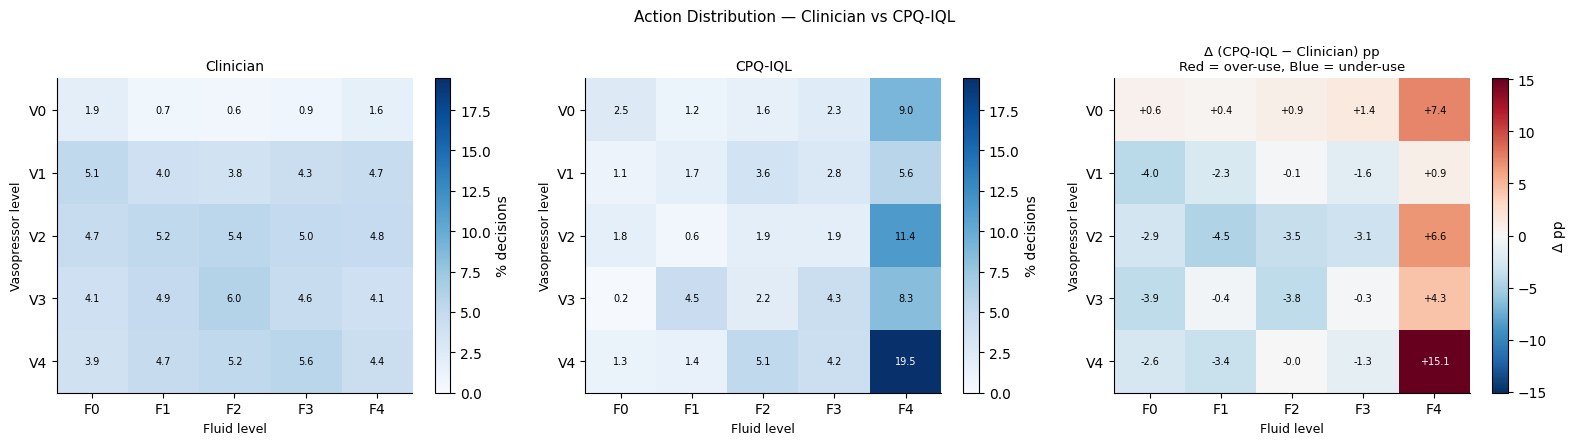

In [16]:
# ── Figure: Action distributions ─────────────────────────────────────────
s_test   = test_split['states']
a_clin   = test_split['actions']
a_policy = np.array([policy.act(s_test[i]) for i in range(len(s_test))], dtype=np.int64)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Action Distribution — Clinician vs CPQ-IQL', fontsize=11)

mats = []
for a_arr in [a_clin, a_policy]:
    mat = np.zeros((5, 5))
    for a in a_arr:
        mat[a % 5, a // 5] += 1
    mats.append(mat / mat.sum() * 100)

v_max = max(mats[0].max(), mats[1].max())
for k, (ax, mat, title) in enumerate(zip(axes[:2], mats, ['Clinician', 'CPQ-IQL'])):
    im = ax.imshow(mat, cmap='Blues', aspect='auto', vmin=0, vmax=v_max)
    ax.set_xticks(range(5))
    ax.set_xticklabels([f'F{i}' for i in range(5)])
    ax.set_yticks(range(5))
    ax.set_yticklabels([f'V{i}' for i in range(5)])
    ax.set_xlabel('Fluid level', fontsize=9)
    ax.set_ylabel('Vasopressor level', fontsize=9)
    ax.set_title(title, fontsize=10)
    for ii in range(5):
        for jj in range(5):
            ax.text(jj, ii, f'{mat[ii,jj]:.1f}', ha='center', va='center',
                    fontsize=7, color='white' if mat[ii,jj] > v_max * 0.6 else 'black')
    plt.colorbar(im, ax=ax, label='% decisions')

diff = mats[1] - mats[0]
lim  = max(abs(diff).max(), 0.5)
im3  = axes[2].imshow(diff, cmap='RdBu_r', aspect='auto', vmin=-lim, vmax=lim)
axes[2].set_xticks(range(5))
axes[2].set_xticklabels([f'F{i}' for i in range(5)])
axes[2].set_yticks(range(5))
axes[2].set_yticklabels([f'V{i}' for i in range(5)])
axes[2].set_xlabel('Fluid level', fontsize=9)
axes[2].set_ylabel('Vasopressor level', fontsize=9)
axes[2].set_title('Δ (CPQ-IQL − Clinician) pp\nRed = over-use, Blue = under-use', fontsize=9.5)
for ii in range(5):
    for jj in range(5):
        axes[2].text(jj, ii, f'{diff[ii,jj]:+.1f}', ha='center', va='center',
                     fontsize=7, color='white' if abs(diff[ii,jj]) > lim * 0.6 else 'black')
plt.colorbar(im3, ax=axes[2], label='Δ pp')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '07_action_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Sensitivity Analysis — Constraint Penalty Coefficient α

The penalty coefficient α scales the Lagrangian constraint penalty relative to the Bellman loss. α=0 is an unconstrained policy; large α causes over-penalisation that degrades BC without further CVR improvement.

Both panels share α on the x-axis:
- **Left**: CVR (primary safety) and BC top-3 (clinician alignment) on dual axes.
- **Right**: SR (patient outcome) and FQE value (offline value estimate) on dual axes.

All variants use the same seed and train/val/test splits for fair comparison.

In [17]:
ALPHA_VALUES       = [0.0, 0.5, 1.0, 2.0, 5.0]
SENSITIVITY_EPOCHS = 150

sensitivity_results = []
for alpha_val in ALPHA_VALUES:
    print(f'\n── α = {alpha_val} ──')
    _save_dir = os.path.join(MODEL_DIR, f'alpha_{alpha_val}')
    _ckpt     = os.path.join(_save_dir, 'best_cpq_iql.pt')

    tr_a = CPQIQLTrainer(
        state_dim=STATE_DIM, n_actions=N_ACTIONS,
        alpha=alpha_val, gamma=GAMMA, tau=0.8,
        beta=5.0, beta_anneal=True, beta_end=1.0,
        lambda_init=1.0,
        lambda_max=[10.0, 10.0, 8.0, 10.0],
        constraint_tol=[0.0, 0.05, 0.0, 0.0],
        penalty_on_advantage=True,
        device=DEVICE, seed=SEED,
    )

    if os.path.isfile(_ckpt):
        tr_a.load(_ckpt)
    else:
        tr_a.fit(
            dataloader=train_loader, val_dataloader=val_loader,
            n_epochs=SENSITIVITY_EPOCHS, save_dir=_save_dir,
            log_every=50, patience=30, min_delta=1e-3,
        )

    pol = tr_a.get_policy()
    cvr = compute_cvr_rollout(pol, test_split, device=DEVICE)
    saf = evaluate_with_safe_actions(pol, test_split)
    bca = compute_bc_accuracy_rollout(pol, test_split, top_k=[1, 3])
    sr  = compute_survival_rate(
        policy=pol, test_split=test_split,
        train_split=splits['train'], device=DEVICE, random_state=SEED)

    fqe_a = FittedQEvaluator(
        state_dim=STATE_DIM, n_actions=N_ACTIONS, gamma=GAMMA,
        hidden=(256, 256), lr=3e-4, n_epochs=80, patience=15,
        batch_size=512, device=DEVICE, seed=SEED)
    fqe_a.fit(splits['train'], splits['val'], pol)
    fqe_res = fqe_a.evaluate(
        test_split, pol,
        compute_wis_empirical_behavior(pol, test_split, gamma=GAMMA, n_actions=N_ACTIONS))

    sensitivity_results.append({
        'alpha'        : alpha_val,
        'CVR_%'        : round(cvr['total_cvr'] * 100, 2),
        'SafeCVR_%'    : round(saf['safe_total_cvr'] * 100, 2),
        'BC_top1_%'    : round(bca['top1'] * 100, 2),
        'BC_top3_%'    : round(bca['top3'] * 100, 2),
        'Intervention%': round(saf['intervention_rate'] * 100, 2),
        'SR_policy_%'  : round(sr['sr_policy'] * 100, 2),
        'FQE_V'        : round(fqe_res['v_fqe'], 4),
    })

df_sens = pd.DataFrame(sensitivity_results)
print('\n')
print(df_sens.to_string(index=False))
df_sens.to_csv(os.path.join(EXP_DIR, 'sensitivity_alpha.csv'), index=False)


── α = 0.0 ──
[load]  Checkpoint loaded: ../models/cpq_iql\alpha_0.0\best_cpq_iql.pt
[load]  λ = ['1.3909', '0.6345', '8.0000', '3.0085']   β = 3.1600
  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 23  (val Bellman loss = 9.8643)

── α = 0.5 ──
[load]  Checkpoint loaded: ../models/cpq_iql\alpha_0.5\best_cpq_iql.pt
[load]  λ = ['1.4338', '0.5957', '8.0000', '3.0091']   β = 2.9467
  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 23  (val Bellman loss = 9.7987)

── α = 1.0 ──
[load]  Checkpoint loaded: ../models/cpq_iql\alpha_1.0\best_cpq_iql.pt
[load]  λ = ['1.4561', '0.5756', '8.0000', '3.0096']   β = 2.8400
  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 23  (val Bellman loss = 9.7234)

── α = 2.0 ──
[load]  Checkpoint loaded: ../models/cpq_iql\alpha_2.0\best_cpq_iql.pt
[load]  λ = ['1.3222', '0.

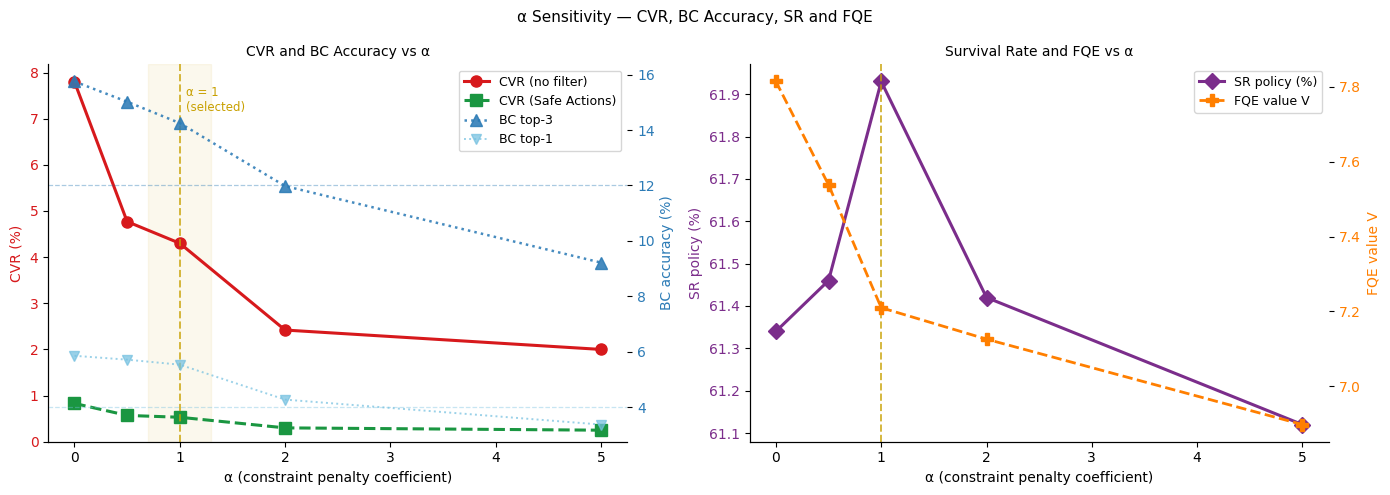

In [18]:
alphas = df_sens['alpha'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('α Sensitivity — CVR, BC Accuracy, SR and FQE', fontsize=11)

# ── Left: CVR + BC ────────────────────────────────────────────────────────
ax1  = axes[0]
ax1b = ax1.twinx()

l1, = ax1.plot(alphas, df_sens['CVR_%'],     'o-',  color='#D7191C', lw=2.2, ms=8, label='CVR (no filter)')
l2, = ax1.plot(alphas, df_sens['SafeCVR_%'], 's--', color='#1A9641', lw=2.2, ms=8, label='CVR (Safe Actions)')
l3, = ax1b.plot(alphas, df_sens['BC_top3_%'], '^:', color='#2C7BB6', lw=1.8, ms=8, alpha=0.88, label='BC top-3')
l4, = ax1b.plot(alphas, df_sens['BC_top1_%'], 'v:', color='#74C0E0', lw=1.4, ms=7, alpha=0.72, label='BC top-1')

ax1b.axhline(300 / N_ACTIONS, color='#2C7BB6', lw=0.9, ls='--', alpha=0.4)
ax1b.axhline(100 / N_ACTIONS, color='#74C0E0', lw=0.9, ls='--', alpha=0.4)
ax1.axvspan(0.7, 1.3, alpha=0.07, color='#C8A000')
ax1.axvline(1.0, color='#C8A000', lw=1.4, ls='--', alpha=0.75)
ax1.text(1.06, df_sens['CVR_%'].max() * 0.92, 'α = 1\n(selected)', fontsize=8.5, color='#C8A000')

ax1.set_xlabel('α (constraint penalty coefficient)', fontsize=10)
ax1.set_ylabel('CVR (%)', color='#D7191C', fontsize=10)
ax1b.set_ylabel('BC accuracy (%)', color='#2C7BB6', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#D7191C')
ax1b.tick_params(axis='y', labelcolor='#2C7BB6')
ax1.set_ylim(bottom=0)
ax1.set_title('CVR and BC Accuracy vs α', fontsize=10)
ax1.legend([l1, l2, l3, l4], [l.get_label() for l in [l1, l2, l3, l4]], fontsize=9)
ax1.spines['top'].set_visible(False)
ax1b.spines['top'].set_visible(False)

# ── Right: SR + FQE ───────────────────────────────────────────────────────
ax2  = axes[1]
ax2b = ax2.twinx()

l5, = ax2.plot(alphas, df_sens['SR_policy_%'], 'D-',  color='#7B2D8B', lw=2.2, ms=8, label='SR policy (%)')
l6, = ax2b.plot(alphas, df_sens['FQE_V'],      'P--', color='#FF7F00', lw=2.0, ms=8, label='FQE value V')

ax2.axvline(1.0, color='#C8A000', lw=1.4, ls='--', alpha=0.75)
ax2.set_xlabel('α (constraint penalty coefficient)', fontsize=10)
ax2.set_ylabel('SR policy (%)', color='#7B2D8B', fontsize=10)
ax2b.set_ylabel('FQE value V', color='#FF7F00', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#7B2D8B')
ax2b.tick_params(axis='y', labelcolor='#FF7F00')
ax2.set_title('Survival Rate and FQE vs α', fontsize=10)
ax2.legend([l5, l6], [l.get_label() for l in [l5, l6]], fontsize=9)
ax2.spines['top'].set_visible(False)
ax2b.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '08_sensitivity_alpha.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Comprehensive Ablation Study

This study isolates the contribution of each algorithmic component and training stage, extending beyond constraint-only ablation.

### Ablation dimensions

**A. Per-Constraint Ablation** — each constraint disabled in turn (tolerance = 1.0), all other components fixed. Measures each constraint's contribution to CVR reduction.

**B. Component Ablation** — key algorithmic choices removed one at a time:

| Variant | What is removed |
|---|---|
| `w/o Twin-Q` | Single Q-network (Q2 frozen as a copy of Q1 after init; no pessimistic min) |
| `w/o β-Annealing` | Fixed β=1.0 throughout (no warm annealing from 5.0) |
| `w/o Adv-Penalty` | Penalty applied to raw Q(s,a) instead of max(0, Q−V) |
| `w/o Lagrangian` | No constraint penalty (α=0) |

**C. Stage Ablation** — incremental benefit of each stage:

| Variant | Configuration |
|---|---|
| `Stage 1 only` | CPQ-IQL without Safe Actions filter |
| `Stage 1 + Filter` | Full two-stage framework |
| `Unconstrained IQL` | IQL with α=0, no constraint penalty — lower bound |

All variants evaluated on the same test split with the same seed. Metrics: CVR, C4-CVR, SR, FQE, BC top-3.

**Checkpoint resume** is used within the ablation loop — if a variant checkpoint already exists it is loaded directly, avoiding redundant retraining.

In [19]:
ABLATION_EPOCHS = 150

# ── A. Per-Constraint Ablation ────────────────────────────────────────────
constraint_ablation_configs = {
    'All constraints': dict(constraint_tol=[0.0, 0.05, 0.0, 0.0], alpha=1.0),
    'w/o C1'         : dict(constraint_tol=[1.0, 0.05, 0.0, 0.0], alpha=1.0),
    'w/o C2'         : dict(constraint_tol=[0.0, 1.0,  0.0, 0.0], alpha=1.0),
    'w/o C3'         : dict(constraint_tol=[0.0, 0.05, 1.0, 0.0], alpha=1.0),
    'w/o C4'         : dict(constraint_tol=[0.0, 0.05, 0.0, 1.0], alpha=1.0),
    'No constraints' : dict(constraint_tol=[1.0, 1.0,  1.0, 1.0], alpha=0.0),
}

# ── B. Component Ablation — twin_q not a CPQIQLTrainer arg ────────────────
# w/o Twin-Q is implemented by cloning Q1 weights into Q2 after init
# (both networks see the same gradients → loss of pessimistic min)
component_ablation_configs = {
    'w/o Twin-Q'     : dict(beta=5.0, beta_anneal=True,  penalty_on_advantage=True,  alpha=1.0, _freeze_twin=True),
    'w/o β-Annealing': dict(beta=1.0, beta_anneal=False, penalty_on_advantage=True,  alpha=1.0, _freeze_twin=False),
    'w/o Adv-Penalty': dict(beta=5.0, beta_anneal=True,  penalty_on_advantage=False, alpha=1.0, _freeze_twin=False),
    'w/o Lagrangian' : dict(beta=5.0, beta_anneal=True,  penalty_on_advantage=True,  alpha=0.0, _freeze_twin=False),
}

ablation_results = []


def _quick_fqe(pol):
    fqe_a = FittedQEvaluator(
        state_dim=STATE_DIM, n_actions=N_ACTIONS, gamma=GAMMA,
        hidden=(256, 256), lr=3e-4, n_epochs=80, patience=15,
        batch_size=512, device=DEVICE, seed=SEED)
    fqe_a.fit(splits['train'], splits['val'], pol)
    return fqe_a.evaluate(
        test_split, pol,
        compute_wis_empirical_behavior(pol, test_split, gamma=GAMMA, n_actions=N_ACTIONS))


def _run_abl(name, abl_type, trainer_kwargs, apply_filter=True):
    # Pop internal flags before passing to CPQIQLTrainer
    kwargs    = dict(trainer_kwargs)           # copy — never mutate the config dict
    freeze_twin = kwargs.pop('_freeze_twin', False)
    beta        = kwargs.pop('beta', 5.0)
    beta_anneal = kwargs.pop('beta_anneal', True)
    pen_adv     = kwargs.pop('penalty_on_advantage', True)

    _save_dir = os.path.join(
        MODEL_DIR, f'ablation_{abl_type}_{name.replace(" ", "_").replace("/", "")}')
    _ckpt = os.path.join(_save_dir, 'best_cpq_iql.pt')

    tr = CPQIQLTrainer(
        state_dim=STATE_DIM, n_actions=N_ACTIONS, gamma=GAMMA,
        tau=0.8, beta=beta, beta_anneal=beta_anneal, beta_end=1.0,
        lambda_init=1.0, lambda_max=[10.0, 10.0, 8.0, 10.0],
        penalty_on_advantage=pen_adv,
        device=DEVICE, seed=SEED,
        **kwargs,                              # alpha, constraint_tol
    )

    # w/o Twin-Q: freeze Q2 as a copy of Q1 — no pessimistic min during training
    if freeze_twin:
        tr.Q2.load_state_dict(tr.Q.state_dict())
        for p in tr.Q2.parameters():
            p.requires_grad_(False)

    if os.path.isfile(_ckpt):
        tr.load(_ckpt)
    else:
        tr.fit(dataloader=train_loader, val_dataloader=val_loader,
               n_epochs=ABLATION_EPOCHS, save_dir=_save_dir,
               log_every=50, patience=30, min_delta=1e-3)

    pol     = tr.get_policy()
    cvr     = compute_cvr_rollout(pol, test_split, device=DEVICE)
    bca     = compute_bc_accuracy_rollout(pol, test_split, top_k=[1, 3])
    saf     = evaluate_with_safe_actions(pol, test_split) if apply_filter else None
    sr      = compute_survival_rate(
        policy=pol, test_split=test_split,
        train_split=splits['train'], device=DEVICE, random_state=SEED)
    fqe_res = _quick_fqe(pol)

    safe_cvr = saf['safe_total_cvr'] * 100 if saf else float('nan')

    ablation_results.append({
        'Category'     : abl_type,
        'Configuration': name,
        'CVR_%'        : round(cvr['total_cvr'] * 100, 2),
        'SafeCVR_%'    : round(safe_cvr, 2),
        'C4_CVR_%'     : round(cvr['C4_withdrawal'] * 100, 2),
        'BC_top1_%'    : round(bca['top1'] * 100, 2),
        'BC_top3_%'    : round(bca['top3'] * 100, 2),
        'SR_policy_%'  : round(sr['sr_policy'] * 100, 2),
        'FQE_V'        : round(fqe_res['v_fqe'], 4),
    })
    print(f'  CVR={cvr["total_cvr"]*100:.2f}%  C4={cvr["C4_withdrawal"]*100:.2f}%  '
          f'BC3={bca["top3"]*100:.1f}%  SR={sr["sr_policy"]*100:.2f}%  FQE={fqe_res["v_fqe"]:.4f}')


# ── Run ablations ──────────────────────────────────────────────────────────
print('\n========  A. Per-Constraint Ablation  ========')
for name, kwargs in constraint_ablation_configs.items():
    print(f'\n── {name} ──')
    _run_abl(name, 'Constraint', dict(**kwargs), apply_filter=True)

print('\n========  B. Component Ablation  ========')
for name, kwargs in component_ablation_configs.items():
    print(f'\n── {name} ──')
    _run_abl(name, 'Component',
             dict(**kwargs, constraint_tol=[0.0, 0.05, 0.0, 0.0]),
             apply_filter=True)

# ── C. Stage Ablation — reuse already-computed results ────────────────────
print('\n========  C. Stage Ablation  ========')

ablation_results.append({
    'Category': 'Stage', 'Configuration': 'Stage 1 only (no filter)',
    'CVR_%'       : round(cvr_result['total_cvr'] * 100, 2),
    'SafeCVR_%'   : float('nan'),
    'C4_CVR_%'    : round(cvr_result['C4_withdrawal'] * 100, 2),
    'BC_top1_%'   : round(bca_result['top1'] * 100, 2),
    'BC_top3_%'   : round(bca_result['top3'] * 100, 2),
    'SR_policy_%' : round(sr_result['sr_policy'] * 100, 2),
    'FQE_V'       : round(fqe_result['v_fqe'], 4),
})
ablation_results.append({
    'Category': 'Stage', 'Configuration': 'Stage 1 + Stage 2 Filter (full)',
    'CVR_%'       : round(cvr_result['total_cvr'] * 100, 2),
    'SafeCVR_%'   : round(safe_result['safe_total_cvr'] * 100, 2),
    'C4_CVR_%'    : round(safe_result['safe_C4_withdrawal'] * 100, 2),
    'BC_top1_%'   : round(bca_result['top1'] * 100, 2),
    'BC_top3_%'   : round(bca_result['top3'] * 100, 2),
    'SR_policy_%' : round(sr_result['sr_policy'] * 100, 2),
    'FQE_V'       : round(fqe_result['v_fqe'], 4),
})
# Unconstrained baseline reuse from constraint ablation
no_c = next(r for r in ablation_results if r['Configuration'] == 'No constraints')
no_c_stage = dict(no_c)
no_c_stage['Category']      = 'Stage'
no_c_stage['Configuration'] = 'Unconstrained IQL (α=0, lower bound)'
ablation_results.append(no_c_stage)

df_abl = pd.DataFrame(ablation_results)
print('\n')
print(df_abl.to_string(index=False))
df_abl.to_csv(os.path.join(EXP_DIR, 'ablation_full.csv'), index=False)


========  A. Per-Constraint Ablation  ========

── All constraints ──
[load]  Checkpoint loaded: ../models/cpq_iql\ablation_Constraint_All_constraints\best_cpq_iql.pt
[load]  λ = ['1.4561', '0.5756', '8.0000', '3.0096']   β = 2.8400
  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 23  (val Bellman loss = 9.7234)
  CVR=4.30%  C4=1.66%  BC3=14.2%  SR=61.93%  FQE=7.2099

── w/o C1 ──
[load]  Checkpoint loaded: ../models/cpq_iql\ablation_Constraint_wo_C1\best_cpq_iql.pt
[load]  λ = ['0.0000', '0.5336', '8.0000', '3.0107']   β = 2.6267
  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 23  (val Bellman loss = 9.6835)
  CVR=4.00%  C4=1.77%  BC3=14.4%  SR=62.26%  FQE=7.1897

── w/o C2 ──
[load]  Checkpoint loaded: ../models/cpq_iql\ablation_Constraint_wo_C2\best_cpq_iql.pt
[load]  λ = ['1.4561', '0.0000', '8.0000', '3.0096']   β = 2.8400
  FQE.fit: preparing training da

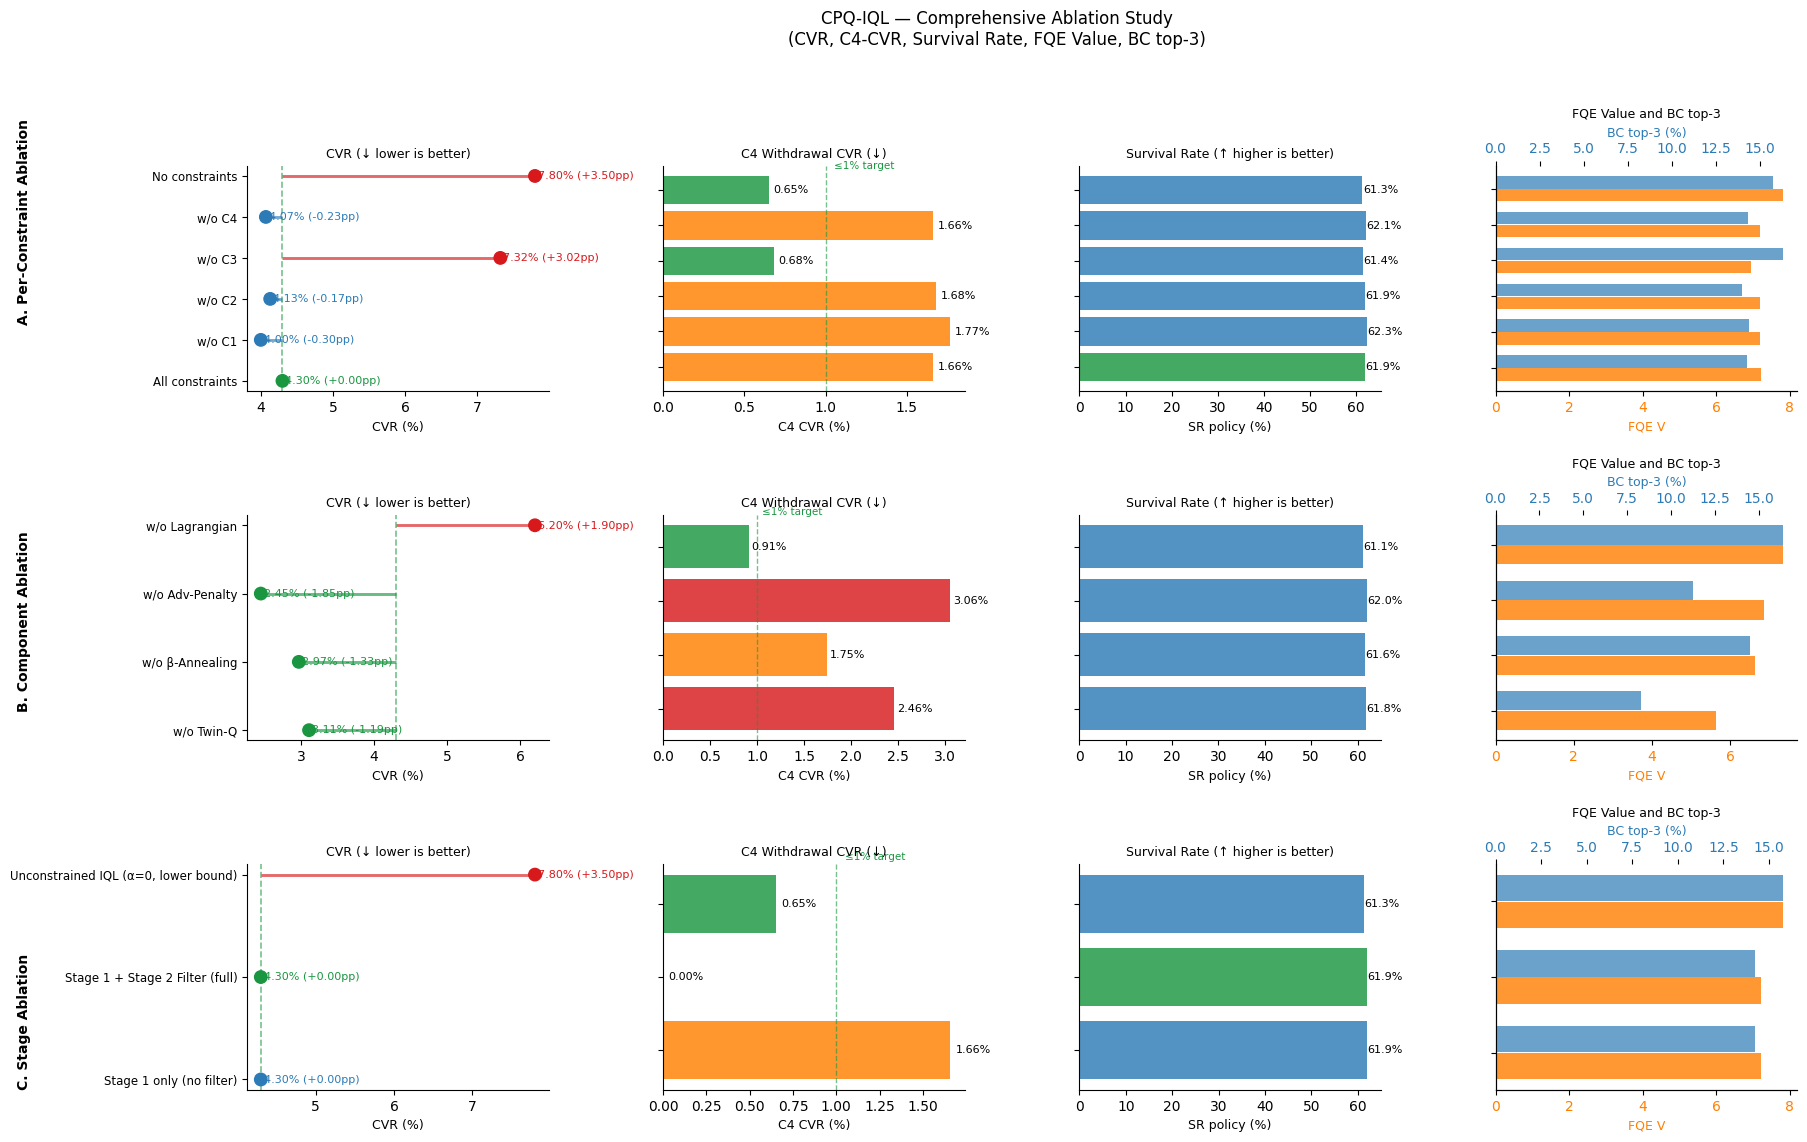

In [20]:
# ── Figure: Comprehensive Ablation ────────────────────────────────────────
categories = ['Constraint', 'Component', 'Stage']
cat_titles  = ['A. Per-Constraint Ablation', 'B. Component Ablation', 'C. Stage Ablation']
ref_config  = 'All constraints'
ref_cvr     = df_abl.loc[df_abl['Configuration'] == ref_config, 'CVR_%'].values[0]
ref_sr      = df_abl.loc[df_abl['Configuration'] == ref_config, 'SR_policy_%'].values[0]
ref_fqe     = df_abl.loc[df_abl['Configuration'] == ref_config, 'FQE_V'].values[0]

fig = plt.figure(figsize=(20, 12))
gs_outer = gridspec.GridSpec(len(categories), 1, figure=fig, hspace=0.55)

def _abl_color(row, col, ref_val, higher_is_better=False):
    v = row[col]
    if row['Configuration'] in (ref_config, 'Stage 1 + Stage 2 Filter (full)'):
        return '#1A9641'
    if pd.isna(v):
        return '#ccc'
    delta = v - ref_val
    if higher_is_better:
        return '#D7191C' if delta < -1.0 else ('#1A9641' if delta > 1.0 else '#2C7BB6')
    return '#D7191C' if delta > 1.0 else ('#1A9641' if delta < -1.0 else '#2C7BB6')

for cat_idx, (cat, cat_title) in enumerate(zip(categories, cat_titles)):
    df_cat = df_abl[df_abl['Category'] == cat].reset_index(drop=True)
    n_rows = len(df_cat)
    y_pos  = np.arange(n_rows)

    gs_inner = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_outer[cat_idx], wspace=0.38)

    # Panel 1: CVR lollipop
    ax_cvr = fig.add_subplot(gs_inner[0])
    colors_cvr = [_abl_color(row, 'CVR_%', ref_cvr, False) for _, row in df_cat.iterrows()]
    ax_cvr.hlines(y_pos, ref_cvr, df_cat['CVR_%'].values, colors=colors_cvr, lw=2.1, alpha=0.65)
    ax_cvr.scatter(df_cat['CVR_%'].values, y_pos, c=colors_cvr, s=80, zorder=4)
    ax_cvr.axvline(ref_cvr, color='#1A9641', lw=1.2, ls='--', alpha=0.6)
    for i, (_, row) in enumerate(df_cat.iterrows()):
        d = row['CVR_%'] - ref_cvr
        ax_cvr.text(row['CVR_%'] + 0.04, i, f'{row["CVR_%"]:.2f}% ({d:+.2f}pp)',
                    va='center', fontsize=8, color=colors_cvr[i])
    ax_cvr.set_yticks(y_pos)
    ax_cvr.set_yticklabels(df_cat['Configuration'], fontsize=8.5)
    ax_cvr.set_xlabel('CVR (%)', fontsize=9)
    ax_cvr.set_title('CVR (↓ lower is better)', fontsize=9)
    ax_cvr.spines[['top', 'right']].set_visible(False)

    # Panel 2: C4 CVR bar
    ax_c4 = fig.add_subplot(gs_inner[1])
    c4_vals   = df_cat['C4_CVR_%'].fillna(0).values
    c4_colors = ['#1A9641' if v <= 1.0 else ('#FF7F00' if v <= 2.0 else '#D7191C')
                 for v in c4_vals]
    ax_c4.barh(y_pos, c4_vals, color=c4_colors, alpha=0.82)
    ax_c4.axvline(1.0, color='#1A9641', lw=1, ls='--', alpha=0.6)
    ax_c4.text(1.05, n_rows - 0.4, '≤1% target', fontsize=7.5, color='#1A9641')
    for i, v in enumerate(c4_vals):
        ax_c4.text(v + 0.03, i, f'{v:.2f}%', va='center', fontsize=8)
    ax_c4.set_yticks(y_pos)
    ax_c4.set_yticklabels([''] * n_rows)
    ax_c4.set_xlabel('C4 CVR (%)', fontsize=9)
    ax_c4.set_title('C4 Withdrawal CVR (↓)', fontsize=9)
    ax_c4.spines[['top', 'right']].set_visible(False)

    # Panel 3: SR bar
    ax_sr = fig.add_subplot(gs_inner[2])
    sr_vals   = df_cat['SR_policy_%'].values
    sr_colors = [_abl_color(row, 'SR_policy_%', ref_sr, True) for _, row in df_cat.iterrows()]
    ax_sr.barh(y_pos, sr_vals, color=sr_colors, alpha=0.82)
    for i, v in enumerate(sr_vals):
        ax_sr.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)
    ax_sr.set_yticks(y_pos)
    ax_sr.set_yticklabels([''] * n_rows)
    ax_sr.set_xlabel('SR policy (%)', fontsize=9)
    ax_sr.set_title('Survival Rate (↑ higher is better)', fontsize=9)
    ax_sr.spines[['top', 'right']].set_visible(False)

    # Panel 4: FQE + BC top-3
    ax_fqe  = fig.add_subplot(gs_inner[3])
    ax_fqe2 = ax_fqe.twiny()
    fqe_vals = df_cat['FQE_V'].values
    bc3_vals = df_cat['BC_top3_%'].values
    ax_fqe.barh(y_pos - 0.18, fqe_vals, 0.35, color='#FF7F00', alpha=0.80, label='FQE V')
    ax_fqe2.barh(y_pos + 0.18, bc3_vals, 0.35, color='#2C7BB6', alpha=0.70, label='BC top-3 %')
    ax_fqe.set_yticks(y_pos)
    ax_fqe.set_yticklabels([''] * n_rows)
    ax_fqe.set_xlabel('FQE V', color='#FF7F00', fontsize=9)
    ax_fqe2.set_xlabel('BC top-3 (%)', color='#2C7BB6', fontsize=9)
    ax_fqe.tick_params(axis='x', labelcolor='#FF7F00')
    ax_fqe2.tick_params(axis='x', labelcolor='#2C7BB6')
    ax_fqe.set_title('FQE Value and BC top-3', fontsize=9)
    ax_fqe.spines[['top', 'right']].set_visible(False)

    fig.text(0.01, 1 - (cat_idx + 0.5) / len(categories),
             cat_title, fontsize=10, fontweight='bold', va='center',
             rotation=90, transform=fig.transFigure)

fig.suptitle('CPQ-IQL — Comprehensive Ablation Study\n'
             '(CVR, C4-CVR, Survival Rate, FQE Value, BC top-3)',
             fontsize=12, y=1.01)
plt.savefig(os.path.join(FIG_DIR, '09_ablation_comprehensive.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Final Results Summary

The summary table consolidates all metrics across the three evaluation regimes:
- **Clinician (behavior)**: dataset reference — all metrics at their observed values.
- **CPQ-IQL (no filter)**: Stage 1 policy only — Lagrangian-penalised Q-learning.
- **CPQ-IQL + Safe Actions**: full two-stage framework.

FQE is the preferred offline value estimator; WIS is reported as a secondary signal for reference. SR quantifies patient-level counterfactual outcome improvement.

In [21]:
C_test   = test_split['constraints']
clin_cvr = float(C_test.mean(axis=0).mean() * 100)

rows = [
    {
        'Method'         : 'Clinician (behavior)',
        'CVR_%'          : round(clin_cvr, 2),
        'SafeCVR_%'      : float('nan'),
        'C4_CVR_%'       : round(C_test.mean(axis=0)[3] * 100, 2),
        'BC_top1_%'      : 100.0,
        'BC_top3_%'      : 100.0,
        'SR_%'           : round(sr_result['sr_clinician'] * 100, 2),
        'FQE_V'          : float('nan'),
        'Intervention_%' : float('nan'),
        'Note'           : 'Dataset reference',
    },
    {
        'Method'         : 'Random policy',
        'CVR_%'          : float('nan'),
        'SafeCVR_%'      : float('nan'),
        'C4_CVR_%'       : float('nan'),
        'BC_top1_%'      : round(100 / N_ACTIONS, 1),
        'BC_top3_%'      : round(300 / N_ACTIONS, 1),
        'SR_%'           : float('nan'),
        'FQE_V'          : float('nan'),
        'Intervention_%' : float('nan'),
        'Note'           : f'Lower bound: 1/{N_ACTIONS} and 3/{N_ACTIONS}',
    },
    {
        'Method'         : 'CPQ-IQL (no filter)',
        'CVR_%'          : round(cvr_result['total_cvr'] * 100, 2),
        'SafeCVR_%'      : float('nan'),
        'C4_CVR_%'       : round(cvr_result['C4_withdrawal'] * 100, 2),
        'BC_top1_%'      : round(bca_result['top1'] * 100, 2),
        'BC_top3_%'      : round(bca_result['top3'] * 100, 2),
        'SR_%'           : round(sr_result['sr_policy'] * 100, 2),
        'FQE_V'          : round(fqe_result['v_fqe'], 4),
        'Intervention_%' : float('nan'),
        'Note'           : 'Stage 1 only',
    },
    {
        'Method'         : 'CPQ-IQL + Safe Actions',
        'CVR_%'          : round(cvr_result['total_cvr'] * 100, 2),
        'SafeCVR_%'      : round(safe_result['safe_total_cvr'] * 100, 2),
        'C4_CVR_%'       : round(safe_result['safe_C4_withdrawal'] * 100, 2),
        'BC_top1_%'      : round(bca_result['top1'] * 100, 2),
        'BC_top3_%'      : round(bca_result['top3'] * 100, 2),
        'SR_%'           : round(sr_result['sr_policy'] * 100, 2),
        'FQE_V'          : round(fqe_result['v_fqe'], 4),
        'Intervention_%' : round(safe_result['intervention_rate'] * 100, 2),
        'Note'           : 'Full two-stage framework',
    },
]

df_results = pd.DataFrame(rows)
print('\n' + '=' * 110)
print('FINAL RESULTS — CPQ-IQL: CVR · C4-CVR · SR · FQE · BC')
print('=' * 110)
print(df_results.to_string(index=False))
print('=' * 110)
df_results.to_csv(os.path.join(EXP_DIR, 'final_results.csv'), index=False)


FINAL RESULTS — CPQ-IQL: CVR · C4-CVR · SR · FQE · BC
                Method  CVR_%  SafeCVR_%  C4_CVR_%  BC_top1_%  BC_top3_%  SR_%  FQE_V  Intervention_%                       Note
  Clinician (behavior)   5.79        NaN      0.02     100.00     100.00 60.02    NaN             NaN          Dataset reference
         Random policy    NaN        NaN       NaN       4.00      12.00   NaN    NaN             NaN Lower bound: 1/25 and 3/25
   CPQ-IQL (no filter)   4.30        NaN      1.66       5.54      14.25 61.93 7.2099             NaN               Stage 1 only
CPQ-IQL + Safe Actions   4.30       0.53      0.00       5.54      14.25 61.93 7.2099            15.0   Full two-stage framework


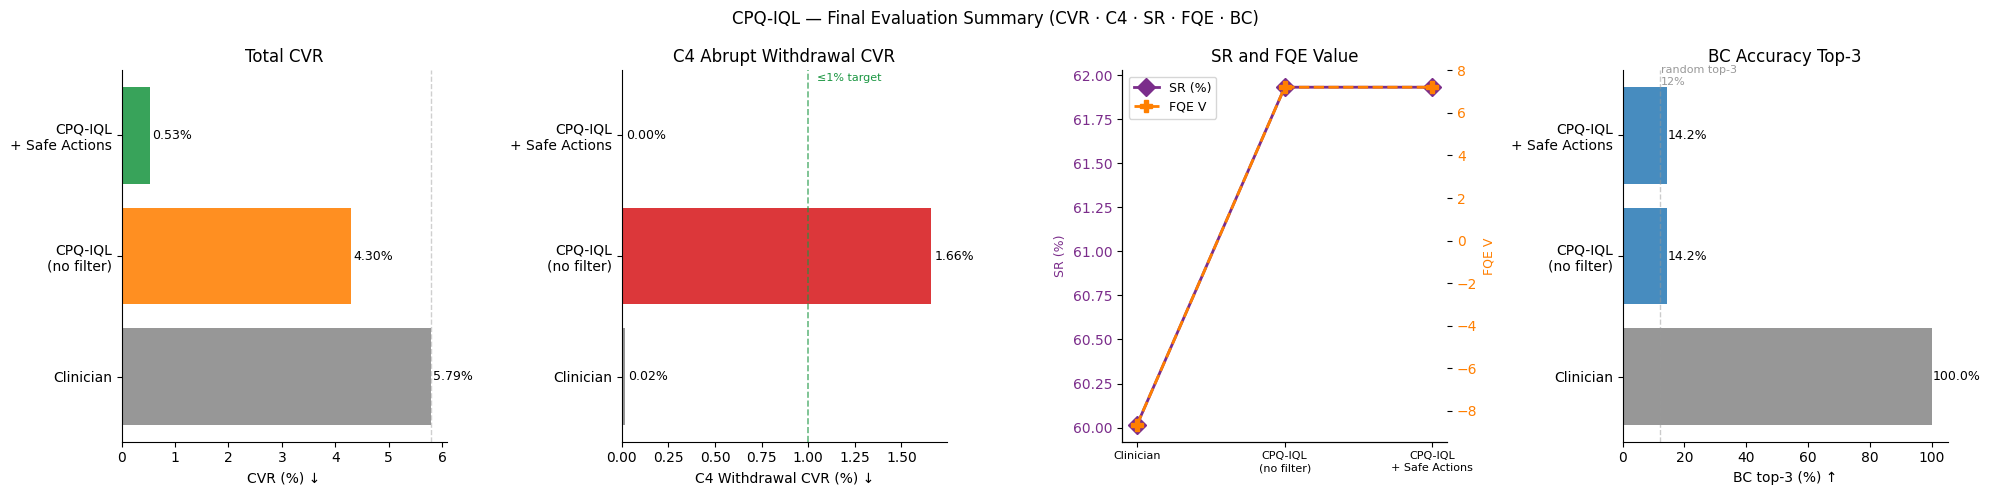

In [22]:
# ── Figure: Final summary ─────────────────────────────────────────────────
methods      = ['Clinician', 'CPQ-IQL\n(no filter)', 'CPQ-IQL\n+ Safe Actions']
cvr_vals     = [clin_cvr,
                cvr_result['total_cvr'] * 100,
                safe_result['safe_total_cvr'] * 100]
c4_vals_plot = [C_test.mean(axis=0)[3] * 100,
                cvr_result['C4_withdrawal'] * 100,
                safe_result['safe_C4_withdrawal'] * 100]
bc3_vals     = [100.0, bca_result['top3'] * 100, bca_result['top3'] * 100]
sr_vals_plot = [sr_result['sr_clinician'] * 100,
                sr_result['sr_policy'] * 100,
                sr_result['sr_policy'] * 100]
fqe_plot     = [fqe_result['v_wis_clinician'],
                fqe_result['v_fqe'],
                fqe_result['v_fqe']]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('CPQ-IQL — Final Evaluation Summary (CVR · C4 · SR · FQE · BC)', fontsize=12)
colors_base = ['#888', '#FF7F00', '#1A9641']

# Panel 1: CVR
ax = axes[0]
bars = ax.barh(methods, cvr_vals, color=colors_base, alpha=0.87)
ax.axvline(clin_cvr, color='#888', lw=1, ls='--', alpha=0.4)
for bar, v in zip(bars, cvr_vals):
    ax.text(v + 0.04, bar.get_y() + bar.get_height()/2, f'{v:.2f}%', va='center', fontsize=9)
ax.set_xlabel('CVR (%) ↓')
ax.set_title('Total CVR')
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: C4 CVR
ax = axes[1]
c4_col = ['#888',
          '#D7191C' if c4_vals_plot[1] > 1.0 else '#1A9641',
          '#1A9641']
bars = ax.barh(methods, c4_vals_plot, color=c4_col, alpha=0.87)
ax.axvline(1.0, color='#1A9641', lw=1.2, ls='--', alpha=0.65)
ax.text(1.05, 2.45, '≤1% target', fontsize=8, color='#1A9641')
for bar, v in zip(bars, c4_vals_plot):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2, f'{v:.2f}%', va='center', fontsize=9)
ax.set_xlabel('C4 Withdrawal CVR (%) ↓')
ax.set_title('C4 Abrupt Withdrawal CVR')
ax.spines[['top', 'right']].set_visible(False)

# Panel 3: SR + FQE on twin axes
ax3  = axes[2]
ax3b = ax3.twinx()
l1, = ax3.plot(range(len(methods)), sr_vals_plot, 'D-', color='#7B2D8B', lw=2, ms=9)
l2, = ax3b.plot(range(len(methods)), fqe_plot,    'P--', color='#FF7F00', lw=2, ms=9)
ax3.set_xticks(range(len(methods)))
ax3.set_xticklabels(methods, fontsize=8)
ax3.set_ylabel('SR (%)', color='#7B2D8B', fontsize=9)
ax3b.set_ylabel('FQE V', color='#FF7F00', fontsize=9)
ax3.tick_params(axis='y', labelcolor='#7B2D8B')
ax3b.tick_params(axis='y', labelcolor='#FF7F00')
ax3.set_title('SR and FQE Value')
ax3.legend([l1, l2], ['SR (%)', 'FQE V'], fontsize=9)
ax3.spines['top'].set_visible(False)
ax3b.spines['top'].set_visible(False)

# Panel 4: BC top-3
ax = axes[3]
bars = ax.barh(methods, bc3_vals, color=['#888', '#2C7BB6', '#2C7BB6'], alpha=0.87)
ax.axvline(300 / N_ACTIONS, color='#999', lw=1, ls='--', alpha=0.5)
ax.text(300 / N_ACTIONS + 0.3, 2.42, f'random top-3\n{300/N_ACTIONS:.0f}%', fontsize=8, color='#999')
for bar, v in zip(bars, bc3_vals):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('BC top-3 (%) ↑')
ax.set_title('BC Accuracy Top-3')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '10_final_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Artifact Export

In [23]:
pd.DataFrame(history).to_csv(HIST_CSV, index=False)

def _safe_serial(obj):
    if isinstance(obj, dict):
        return {k: _safe_serial(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_safe_serial(v) for v in obj]
    if hasattr(obj, 'item'):
        return obj.item()
    return obj

all_results = {
    'cvr_rollout'  : _safe_serial(cvr_result),
    'safe_actions' : {k: v for k, v in safe_result.items() if not isinstance(v, list)},
    'bc_accuracy'  : _safe_serial(dict(bca_result)),
    'survival_rate': _safe_serial(sr_result),
    'fqe'          : _safe_serial(fqe_result),
}
with open(os.path.join(EXP_DIR, 'all_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print('=' * 65)
print('Exported artifacts')
print('=' * 65)
for dirpath in [MODEL_DIR, EXP_DIR, FIG_DIR]:
    if not os.path.isdir(dirpath):
        continue
    for fn in sorted(os.listdir(dirpath)):
        fp = os.path.join(dirpath, fn)
        if os.path.isfile(fp):
            rel = os.path.relpath(fp, '..')
            print(f'  {rel:<60} {os.path.getsize(fp)/1e3:>8.1f} KB')

Exported artifacts
  models\cpq_iql\best_cpq_iql.pt                                 1391.2 KB
  models\cpq_iql\final_cpq_iql.pt                                1401.8 KB
  experiments\ablation_constraints.csv                              0.3 KB
  experiments\ablation_full.csv                                     0.9 KB
  experiments\all_results.json                                     10.1 KB
  experiments\cpq_iql_training_history.csv                         32.6 KB
  experiments\final_results.csv                                     0.4 KB
  experiments\sensitivity_alpha.csv                                 0.3 KB
  experiments\training_history.csv                                 31.1 KB
  figures\cpq_iql\00_clinician_baseline.png                        94.0 KB
  figures\cpq_iql\00_clinician_violations.png                      30.9 KB
  figures\cpq_iql\01_clinician_baseline.png                        97.7 KB
  figures\cpq_iql\01_training_curves.png                          166.2 KB
  figu